# Visualización Comparativa - Índices de Precios de Vivienda (INE)

**Autor:** TFM - Forecasting del Mercado Inmobiliario Español  
**Fecha:** Octubre 2025  
**Objetivo:** Visualización comparativa de IPV (trimestral) e IPVA (anual)

---

## Objetivo

Este notebook presenta una visualización comparativa de los dos principales índices de precios de vivienda del INE:

- **IPV (Índice de Precios de Vivienda)**: Frecuencia trimestral, basado en precios de compraventa
- **IPVA (Índice de Precios de Vivienda en Avalúo)**: Frecuencia anual, basado en valores de avalúo

Ambos índices se muestran en el mismo gráfico para permitir la comparación de tendencias.

## 1. Configuración y Librerías

In [6]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

# Configuración de estilo
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (15, 10)
plt.rcParams["font.size"] = 12
pd.set_option("display.float_format", "{:.2f}".format)

print("✅ Librerías cargadas y configuradas correctamente")

✅ Librerías cargadas y configuradas correctamente


## 2. Carga y Filtrado de Datos

In [7]:
# Cargar datos IPV (trimestral)
print("📊 Cargando datos IPV (trimestral)...")
df_ipv = pd.read_csv("../data/raw/data-INE/INE_IPV.csv", sep=";", encoding="utf-8")
print(f"   Total registros IPV: {len(df_ipv):,}")

# Filtrar IPV correctamente
df_ipv_filt = df_ipv[
    (df_ipv["Total Nacional"] == "Nacional") & 
    (df_ipv["Comunidades y Ciudades Autónomas"].isna()) & 
    (df_ipv["General, vivienda nueva y de segunda mano"] == "General") & 
    (df_ipv["Índices y tasas"] == "Índice")
].copy()

# Procesar IPV
df_ipv_filt["valor"] = df_ipv_filt["Total"].str.replace(",", ".").astype(float)
df_ipv_filt["año"] = df_ipv_filt["Periodo"].str.extract(r"(\d{4})").astype(int)
df_ipv_filt["trimestre"] = df_ipv_filt["Periodo"].str.extract(r"T(\d)").astype(int)
df_ipv_filt["fecha"] = pd.to_datetime(df_ipv_filt["año"].astype(str) + "-" + 
                                      (df_ipv_filt["trimestre"] * 3 - 2).astype(str).str.zfill(2) + "-01")
df_ipv_filt = df_ipv_filt.sort_values("fecha").reset_index(drop=True)

# Filtrar desde 2015
df_ipv_final = df_ipv_filt[df_ipv_filt["año"] >= 2015].copy()
print(f"   Registros IPV filtrados: {len(df_ipv_final)}")
print(f"   Período IPV: {df_ipv_final["fecha"].min().strftime("%Y-%m")} - {df_ipv_final["fecha"].max().strftime("%Y-%m")}")
print(f"   Rango valores IPV: {df_ipv_final["valor"].min():.2f} - {df_ipv_final["valor"].max():.2f}")

📊 Cargando datos IPV (trimestral)...
   Total registros IPV: 17,760
   Registros IPV filtrados: 42
   Período IPV: 2015-01 - 2025-04
   Rango valores IPV: 96.65 - 178.18


In [8]:
# Cargar datos IPVA (anual)
print("📊 Cargando datos IPVA (anual)...")
df_ipva = pd.read_csv("../data/raw/data-INE/INE_IPVA.csv", sep=";", encoding="utf-8")
print(f"   Total registros IPVA: {len(df_ipva):,}")

# Filtrar IPVA
df_ipva_filt = df_ipva[
    (df_ipva["Total Nacional"] == "Total Nacional") & 
    (df_ipva["Provincias"].isna()) & 
    (df_ipva["Tamaño de la vivienda"] == "Total") & 
    (df_ipva["Tipo de dato"] == "Índice")
].copy()

# Procesar IPVA
df_ipva_filt["valor"] = df_ipva_filt["Total"].str.replace(",", ".").astype(float)
df_ipva_filt["año"] = df_ipva_filt["Periodo"].astype(int)
df_ipva_filt["fecha"] = pd.to_datetime(df_ipva_filt["año"].astype(str) + "-01-01")
df_ipva_filt = df_ipva_filt.sort_values("fecha").reset_index(drop=True)

# Filtrar desde 2015
df_ipva_final = df_ipva_filt[df_ipva_filt["año"] >= 2015].copy()
print(f"   Registros IPVA filtrados: {len(df_ipva_final)}")
print(f"   Período IPVA: {df_ipva_final["fecha"].min().strftime("%Y-%m")} - {df_ipva_final["fecha"].max().strftime("%Y-%m")}")
print(f"   Rango valores IPVA: {df_ipva_final["valor"].min():.2f} - {df_ipva_final["valor"].max():.2f}")

📊 Cargando datos IPVA (anual)...
   Total registros IPVA: 8,918
   Registros IPVA filtrados: 9
   Período IPVA: 2015-01 - 2023-01
   Rango valores IPVA: 100.00 - 118.73


In [13]:
df_ipva_final["valor"]

4    100.00
5    101.68
6    103.53
7    106.25
8    110.00
9    110.94
10   112.69
11   115.68
12   118.73
Name: valor, dtype: float64

## 3. Visualización Comparativa

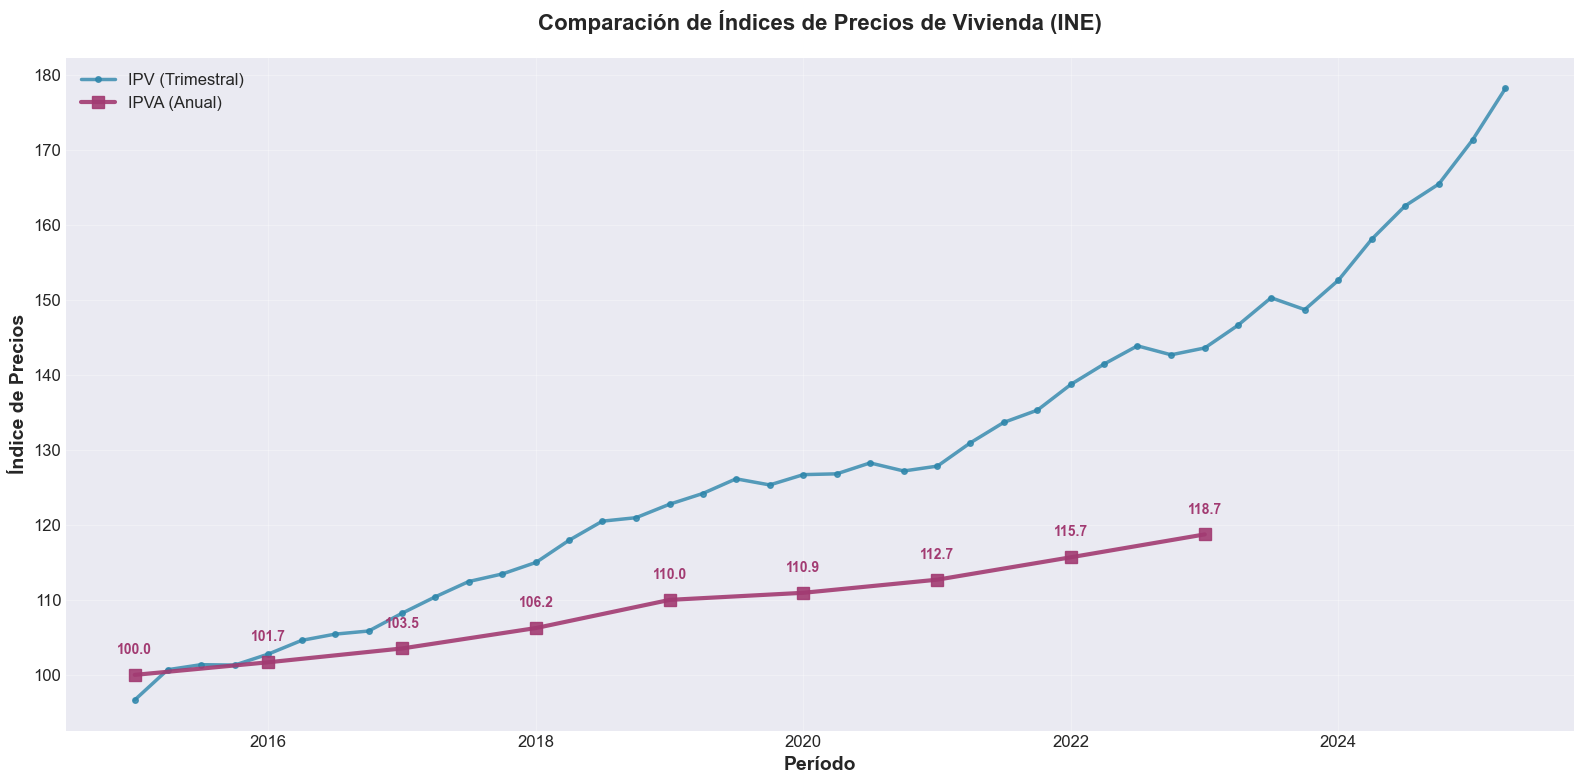

In [11]:
import matplotlib.pyplot as plt

# Crear visualización comparativa simple
plt.figure(figsize=(16, 8))

# Gráfico: Comparación temporal
plt.plot(df_ipv_final["fecha"], df_ipv_final["valor"], marker="o", linewidth=2.5, markersize=4, color="#2E86AB", alpha=0.8, label="IPV (Trimestral)")
plt.plot(df_ipva_final["fecha"], df_ipva_final["valor"], marker="s", linewidth=3, markersize=8, color="#A23B72", alpha=0.9, label="IPVA (Anual)")

plt.title("Comparación de Índices de Precios de Vivienda (INE)", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Período", fontsize=14, fontweight="bold")
plt.ylabel("Índice de Precios", fontsize=14, fontweight="bold")
plt.legend(fontsize=12, loc="upper left")
plt.grid(True, alpha=0.3)

# Añadir valores en puntos clave del IPVA
for i, row in df_ipva_final.iterrows():
    plt.annotate(f"{row['valor']:.1f}", (row["fecha"], row["valor"]),
                 textcoords="offset points", xytext=(0,15),
                 ha="center", fontsize=10, fontweight="bold", color="#A23B72")

plt.tight_layout()

# Guardar como JPG
plt.savefig("comparacion_indices.jpg", format="jpg", dpi=300)

# Mostrar el gráfico
plt.show()
